In [1]:
# Project 5: Spam Detection Using Naive Bayes + TF-IDF

# step 1: importing the libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
# step 2: load the dataset using github

url = "https://raw.githubusercontent.com/programmer-sahil/Ardent_ML_Training/main/Project%205/spam_dataset.csv"
df = pd.read_csv(url)
print(df.head())

  label                                            message
0   ham         Hey! Are we still meeting for lunch today?
1   ham                               I'll call you later.
2  spam  Congratulations! You've won a $500 gift card. ...
3  spam  URGENT! Your account has been suspended. Click...
4   ham      Don't forget to bring the documents tomorrow.


In [3]:
# step 3: Encode labels

df['label_encoded'] = df['label'].map({'ham': 0, 'spam': 1})
print(df.head)

# Why? ML algorithms need numbers, not words


<bound method NDFrame.head of    label                                            message  label_encoded
0    ham         Hey! Are we still meeting for lunch today?              0
1    ham                               I'll call you later.              0
2   spam  Congratulations! You've won a $500 gift card. ...              1
3   spam  URGENT! Your account has been suspended. Click...              1
4    ham      Don't forget to bring the documents tomorrow.              0
5    ham             Happy birthday! Wish you all the best.              0
6   spam  Win a FREE vacation to Bahamas! Text WIN to 90...              1
7   spam  You have been selected for a free prize. Call ...              1
8    ham                   Please find the attached report.              0
9    ham         Can you send me the photos from yesterday?              0
10  spam          Limited time offer!!! Buy 1 Get 1 FREE!!!              1
11  spam                   Claim your lottery winnings now!           

In [4]:
# step 4: Train / Test Split

X_train, X_test, y_train, y_test = train_test_split(
    df['message'],
    df['label_encoded'],
    test_size=0.2,
    random_state=42
)

'''
train → learning

test → evaluation

20% test gives good balance
'''

In [7]:
#step 5: TF-IDF Vectorization

tfidf = TfidfVectorizer(stop_words='english')

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

# TF-IDF converts text to numbers by weighting important words like:
# "FREE", "OFFER", "WIN", "PRIZE"

In [8]:
# step 6: Train Naive Bayes Model

model = MultinomialNB()
model.fit(X_train_tfidf, y_train)

'''
Why Naive Bayes?
Very fast, Works great for text, low memory usuage
'''

'\nWhy Naive Bayes?\nVery fast, Works great for text, low memory usuage\n'

In [9]:
# step 7: Make Predictions

y_pred = model.predict(X_test_tfidf)

In [11]:
# step 8: Evaluate Model

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=['ham', 'spam']))
print("\n Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

'''
Accuracy: overall correctness
Precision: quality of spam predictions
Recall: how many spam messages were caught
Confusion Matrix: breakdown of TP, TN, FP, FN
'''

Accuracy: 0.875

Classification Report:
               precision    recall  f1-score   support

         ham       1.00      0.83      0.91         6
        spam       0.67      1.00      0.80         2

    accuracy                           0.88         8
   macro avg       0.83      0.92      0.85         8
weighted avg       0.92      0.88      0.88         8


 Confusion Matrix:
 [[5 1]
 [0 2]]


'\nAccuracy: overall correctness\nPrecision: quality of spam predictions\nRecall: how many spam messages were caught\nConfusion Matrix: breakdown of TP, TN, FP, FN\n'

**Step 9: Try Custom User Input**

In [12]:
sample_msgs=[
    "Congratulations! You have won a FREE prize. Call now!",
    "Hey bro, are we still meeting tomorrow?"
]

sample_tfidf = tfidf.transform(sample_msgs)
print(model.predict(sample_tfidf))

[1 0]


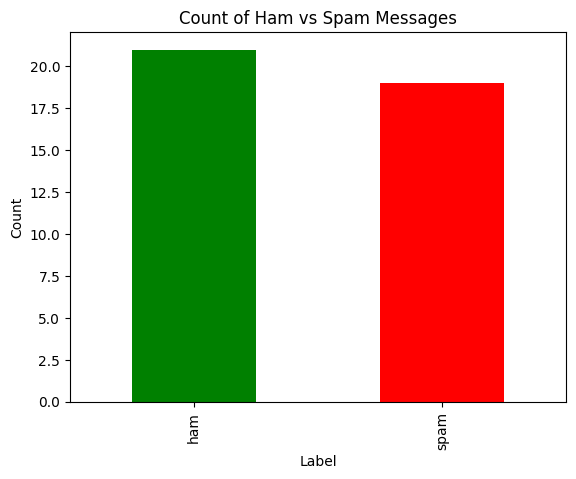

In [13]:
# Optional Step: Bar Chart of Spam vs Ham Distribution

import matplotlib.pyplot as plt

df['label'].value_counts().plot(kind='bar', color=['green', 'red'])
plt.title('Count of Ham vs Spam Messages')
plt.xlabel('Label')
plt.ylabel('Count')
plt.show()


In [ ]:
<!DOCTYPE html>
<html lang="en">
<head>
  <meta charset="UTF-8" />
  <title>CSE 8th Sem ML Portfolio | Swami Vivekananda Institute of Science & Technology</title>
  <meta name="viewport" content="width=device-width, initial-scale=1.0" />

  <!-- Google Font -->
  <link href="https://fonts.googleapis.com/css2?family=Poppins:wght@300;400;500;600;700&display=swap" rel="stylesheet">

  <style>
    :root {
  --bg: #050816;
  --accent: #7c3aed;
  --accent-soft: rgba(124, 58, 237, 0.25);
  --accent-2: #22c55e;
  --text: #e5e7eb;
  --muted: #9ca3af;
  --card-bg: rgba(15, 23, 42, 0.9);
  --glass: rgba(15,23,42,0.75);
  --border-subtle: rgba(148, 163, 184, 0.2);
  --radius-lg: 1.25rem;
  --transition: 0.25s ease;
  --max-width: 1100px;
}

* {
  box-sizing: border-box;
  margin: 0;
  padding: 0;
  scroll-behavior: smooth;
}

/* 🎥 VIDEO BACKGROUND LAYER */
.video-bg {
  position: fixed;
  inset: 0;
  width: 100%;
  height: 100%;
  object-fit: cover;
  z-index: -5;
}

/* 🌑 DARK OVERLAY ON TOP OF VIDEO */
.video-overlay {
  position: fixed;
  inset: 0;
  background: rgba(0,0,0,0.45);
  backdrop-filter: blur(1px);
  z-index: -4;
}

body {
  font-family: 'Poppins', sans-serif;
  background: radial-gradient(circle at top left, #1e293b, #020617 55%, #000000);
  color: var(--text);
  min-height: 100vh;
  overflow-x: hidden;
  position: relative;
}

/* 🌈 Animated gradient overlay ABOVE video */
body::before {
  content: "";
  position: fixed;
  inset: -50%;
  background: conic-gradient(
    from 180deg,
    rgba(124,58,237,0.18),
    rgba(56,189,248,0.15),
    rgba(250,204,21,0.08),
    rgba(124,58,237,0.18)
  );
  animation: spin 30s linear infinite;
  opacity: 0.65;
  z-index: -3;
}

@keyframes spin {
  from { transform: rotate(0deg); }
  to   { transform: rotate(360deg); }
}

/* 🌌 Page darkening layer ABOVE gradients */
.page-overlay {
  position: fixed;
  inset: 0;
  background: radial-gradient(circle at top, rgba(15,23,42,0.7), rgba(15,23,42,0.95));
  z-index: -2;
}

/* Layout */
.container {
  max-width: var(--max-width);
  margin: 0 auto;
  padding: 0 1.25rem;
}

header {
  position: sticky;
  top: 0;
  z-index: 40;
  backdrop-filter: blur(16px);
  background: linear-gradient(to bottom, rgba(15,23,42,0.9), transparent);
  border-bottom: 1px solid var(--border-subtle);
}

.nav {
  display: flex;
  align-items: center;
  justify-content: space-between;
  padding: 0.6rem 0;
}

.brand {
  display: flex;
  align-items: center;
  gap: 0.5rem;
}

.brand-logo {
  width: 34px;
  height: 34px;
  border-radius: 999px;
  background: radial-gradient(circle at 30% 30%, #facc15, #0f172a);
  display: flex;
  align-items: center;
  justify-content: center;
  font-weight: 700;
  color: #0f172a;
  font-size: 0.95rem;
  box-shadow: 0 0 18px rgba(250, 204, 21, 0.4);
}

.brand-text {
  display: flex;
  flex-direction: column;
  line-height: 1.1;
}

.brand-text span:first-child {
  font-weight: 600;
  font-size: 0.95rem;
}

.brand-text span:last-child {
  font-weight: 400;
  font-size: 0.72rem;
  color: var(--muted);
}

nav ul {
  list-style: none;
  display: flex;
  align-items: center;
  gap: 1.2rem;
}

nav a {
  color: var(--muted);
  text-decoration: none;
  font-size: 0.85rem;
  position: relative;
  padding-bottom: 0.2rem;
  transition: color var(--transition);
}

nav a::after {
  content: "";
  position: absolute;
  left: 0;
  bottom: 0;
  width: 0;
  height: 2px;
  border-radius: 4px;
  background: linear-gradient(to right, var(--accent), var(--accent-2));
  transition: width var(--transition);
}

nav a:hover,
nav a.active {
  color: #e5e7eb;
}

nav a:hover::after,
nav a.active::after {
  width: 100%;
}

/* Mobile nav button */
.nav-toggle {
  display: none;
  width: 32px;
  height: 32px;
  border-radius: 999px;
  border: 1px solid var(--border-subtle);
  background: rgba(15,23,42,0.8);
  color: var(--text);
  align-items: center;
  justify-content: center;
  cursor: pointer;
}

.nav-toggle span {
  width: 18px;
  height: 2px;
  background: var(--text);
  border-radius: 999px;
  position: relative;
}

.nav-toggle span::before,
.nav-toggle span::after {
  content: "";
  position: absolute;
  left: 0;
  width: 18px;
  height: 2px;
  background: var(--text);
  border-radius: 999px;
  transition: transform 0.25s ease, opacity 0.25s ease;
}

.nav-toggle span::before { top: -6px; }
.nav-toggle span::after { top: 6px; }

.nav-toggle.active span { background: transparent; }

.nav-toggle.active span::before {
  transform: translateY(6px) rotate(45deg);
}
.nav-toggle.active span::after {
  transform: translateY(-6px) rotate(-45deg);
}

/* Hero */
.hero {
  padding: 2.8rem 0 2.5rem;
  display: grid;
  grid-template-columns: minmax(0, 1.4fr) minmax(0, 1fr);
  align-items: center;
  gap: 1.8rem;
}

.hero-badge {
  display: inline-flex;
  align-items: center;
  gap: 0.5rem;
  padding: 0.2rem 0.8rem;
  border-radius: 999px;
  border: 1px solid var(--border-subtle);
  background: rgba(15,23,42,0.8);
  font-size: 0.7rem;
  color: var(--muted);
  margin-bottom: 0.6rem;
}

.hero-badge span {
  display: inline-flex;
  align-items: center;
  justify-content: center;
  width: 20px;
  height: 20px;
  border-radius: 999px;
  background: radial-gradient(circle, var(--accent), #0f172a);
  color: #f9fafb;
  font-size: 0.7rem;
}

.hero h1 {
  font-size: clamp(1.9rem, 3vw, 2.4rem);
  line-height: 1.15;
  margin-bottom: 0.5rem;
}

.hero h1 span.highlight {
  background: linear-gradient(to right, #a855f7, #22c55e);
  -webkit-background-clip: text;
  background-clip: text;
  color: transparent;
}

.hero-sub {
  font-size: 0.92rem;
  color: var(--muted);
  max-width: 34rem;
  margin-bottom: 1rem;
}

.tagline {
  display: flex;
  flex-wrap: wrap;
  gap: 0.35rem;
  margin-bottom: 1.35rem;
}

.tag-pill {
  font-size: 0.7rem;
  padding: 0.22rem 0.7rem;
  border-radius: 999px;
  border: 1px solid rgba(148,163,184,0.35);
  background: rgba(15,23,42,0.85);
  color: var(--muted);
}

.hero-actions {
  display: flex;
  flex-wrap: wrap;
  gap: 0.9rem;
  margin-bottom: 1.4rem;
}

.btn-primary {
  border-radius: 999px;
  padding: 0.6rem 1.35rem;
  border: none;
  cursor: pointer;
  background: radial-gradient(circle at top left, #f97316, #a855f7);
  color: #f9fafb;
  font-size: 0.9rem;
  font-weight: 500;
  display: inline-flex;
  align-items: center;
  gap: 0.35rem;
  box-shadow: 0 15px 35px rgba(15,23,42,0.8);
  transition: transform var(--transition), box-shadow var(--transition), filter var(--transition);
}

.btn-primary:hover {
  transform: translateY(-1px);
  filter: brightness(1.05);
  box-shadow: 0 18px 40px rgba(15,23,42,0.9);
}

.btn-ghost {
  border-radius: 999px;
  padding: 0.6rem 1.25rem;
  border: 1px solid var(--border-subtle);
  background: rgba(15,23,42,0.85);
  color: var(--muted);
  font-size: 0.9rem;
  display: inline-flex;
  align-items: center;
  gap: 0.35rem;
  cursor: pointer;
  transition: background var(--transition), border-color var(--transition), color var(--transition), transform var(--transition);
}

.btn-ghost:hover {
  background: rgba(15,23,42,0.95);
  border-color: var(--accent);
  color: #e5e7eb;
  transform: translateY(-1px);
}

.hero-meta {
  display: flex;
  align-items: center;
  gap: 0.8rem;
  font-size: 0.78rem;
  color: var(--muted);
}

.hero-meta-item {
  display: flex;
  align-items: center;
  gap: 0.35rem;
}

.hero-meta-dot {
  width: 7px;
  height: 7px;
  border-radius: 999px;
  background: #22c55e;
  box-shadow: 0 0 10px rgba(34,197,94,0.6);
}

/* Hero Right Card */
.hero-right {
  display: flex;
  align-items: center;
  justify-content: center;
}

.hero-card {
  width: 100%;
  max-width: 340px;
  aspect-ratio: 3/4;
  border-radius: 1.5rem;
  border: 1px solid rgba(148,163,184,0.35);
  background: radial-gradient(circle at top, rgba(148,163,184,0.2), rgba(15,23,42,0.95));
  box-shadow: 0 25px 50px rgba(15,23,42,0.9);
  padding: 1.1rem;
  position: relative;
  overflow: hidden;
}

.hero-card::before {
  content: "";
  position: absolute;
  inset: -30%;
  background: radial-gradient(circle at 0 0, rgba(244,114,182,0.28), transparent 55%);
  opacity: 0.9;
  mix-blend-mode: screen;
  animation: floatGlow 10s ease-in-out infinite alternate;
}

@keyframes floatGlow {
  0% { transform: translate(0, 0); }
  100% { transform: translate(18px, 8px); }
}

.hero-card-inner {
  position: relative;
  z-index: 1;
  display: flex;
  flex-direction: column;
  height: 100%;
  justify-content: space-between;
}

.hero-avatar {
  display: flex;
  align-items: center;
  gap: 0.7rem;
  margin-bottom: 0.6rem;
}

.hero-avatar-circle {
  width: 46px;
  height: 46px;
  border-radius: 999px;
  border: 2px solid rgba(148,163,184,0.8);
  background: radial-gradient(circle at 30% 30%, #fbbf24, #020617);
  display: flex;
  align-items: center;
  justify-content: center;
  font-weight: 700;
  color: #0f172a;
  font-size: 1rem;
  box-shadow: 0 0 20px rgba(250,204,21,0.5);
}

.hero-avatar-text span:first-child {
  font-size: 0.85rem;
  font-weight: 500;
}

.hero-avatar-text span:last-child {
  font-size: 0.7rem;
  color: var(--muted);
}

.chip-row {
  display: flex;
  flex-wrap: wrap;
  gap: 0.35rem;
  margin: 0.4rem 0 0.6rem;
}

.chip {
  font-size: 0.68rem;
  padding: 0.15rem 0.6rem;
  border-radius: 999px;
  background: rgba(15,23,42,0.9);
  border: 1px solid rgba(148,163,184,0.35);
  color: var(--muted);
}

.hero-card-stats {
  display: grid;
  grid-template-columns: repeat(3, 1fr);
  gap: 0.4rem;
  margin-top: 0.4rem;
}

.stat-card {
  border-radius: 0.8rem;
  border: 1px solid rgba(148,163,184,0.35);
  background: rgba(15,23,42,0.92);
  padding: 0.45rem 0.4rem;
  text-align: left;
}

.stat-card span:first-child {
  font-size: 0.7rem;
  color: var(--muted);
}

.stat-card span:last-child {
  font-size: 0.9rem;
  font-weight: 600;
}

.hero-card-footer {
  font-size: 0.72rem;
  color: var(--muted);
  border-top: 1px dashed rgba(148,163,184,0.5);
  padding-top: 0.5rem;
  margin-top: 0.6rem;
}

/* Sections */
section {
  padding: 1.8rem 0;
}

.section-header {
  margin-bottom: 1rem;
  display: flex;
  flex-direction: column;
  gap: 0.1rem;
}

.section-kicker {
  font-size: 0.75rem;
  color: var(--accent-2);
  text-transform: uppercase;
  letter-spacing: 0.08em;
}

.section-title {
  font-size: 1.25rem;
  font-weight: 600;
}

.section-subtitle {
  font-size: 0.85rem;
  color: var(--muted);
  max-width: 34rem;
}

/* About */
.about-grid {
  display: grid;
  grid-template-columns: minmax(0, 1.4fr) minmax(0, 1fr);
  gap: 1.4rem;
}

.about-text {
  font-size: 0.86rem;
  color: var(--muted);
  line-height: 1.6;
}

.about-card {
  border-radius: var(--radius-lg);
  border: 1px solid var(--border-subtle);
  background: var(--glass);
  padding: 1rem;
  font-size: 0.8rem;
  color: var(--muted);
}

.about-list {
  margin-top: 0.6rem;
  display: grid;
  gap: 0.4rem;
}

.about-item {
  display: flex;
  align-items: flex-start;
  gap: 0.4rem;
}

.about-item-bullet {
  width: 8px;
  height: 8px;
  border-radius: 999px;
  background: var(--accent);
  margin-top: 0.18rem;
}

/* Skills */
.skills-grid {
  display: grid;
  grid-template-columns: repeat(auto-fit, minmax(160px, 1fr));
  gap: 0.7rem;
}

.skill-card {
  border-radius: 0.9rem;
  border: 1px solid var(--border-subtle);
  background: rgba(15,23,42,0.9);
  padding: 0.8rem;
  font-size: 0.8rem;
}

.skill-title {
  font-size: 0.88rem;
  font-weight: 500;
  margin-bottom: 0.4rem;
}

.skill-tags {
  display: flex;
  flex-wrap: wrap;
  gap: 0.25rem;
}

.skill-tag {
  font-size: 0.7rem;
  padding: 0.18rem 0.55rem;
  border-radius: 999px;
  background: rgba(15,23,42,0.9);
  border: 1px solid rgba(148,163,184,0.4);
  color: var(--muted);
}

/* Projects */
.projects-grid {
  display: grid;
  grid-template-columns: repeat(auto-fit, minmax(240px, 1fr));
  gap: 1rem;
  margin-top: 0.5rem;
}

.project-card {
  border-radius: var(--radius-lg);
  border: 1px solid var(--border-subtle);
  background: rgba(15,23,42,0.9);
  padding: 0.9rem;
  position: relative;
  overflow: hidden;
  transition: transform var(--transition), box-shadow var(--transition), border-color var(--transition), background var(--transition);
}

.project-card::before {
  content: "";
  position: absolute;
  inset: -40%;
  background: conic-gradient(
    from 180deg,
    rgba(124,58,237,0.2),
    rgba(34,197,94,0.2),
    transparent 65%
  );
  opacity: 0;
  transition: opacity 0.4s ease;
  z-index: -1;
}

.project-card:hover::before {
  opacity: 1;
}

.project-card:hover {
  transform: translateY(-4px);
  box-shadow: 0 22px 45px rgba(15,23,42,0.9);
  border-color: rgba(129,140,248,0.7);
  background: rgba(15,23,42,0.97);
}

.project-pill {
  font-size: 0.7rem;
  color: var(--accent-2);
  margin-bottom: 0.2rem;
}

.project-title {
  font-size: 0.95rem;
  font-weight: 500;
  margin-bottom: 0.35rem;
}

.project-desc {
  font-size: 0.8rem;
  color: var(--muted);
  margin-bottom: 0.6rem;
}

.project-meta {
  display: flex;
  flex-wrap: wrap;
  justify-content: space-between;
  align-items: center;
  gap: 0.4rem;
  font-size: 0.74rem;
  color: var(--muted);
}

.project-tech {
  display: flex;
  flex-wrap: wrap;
  gap: 0.25rem;
}

.project-tech span {
  padding: 0.12rem 0.5rem;
  border-radius: 999px;
  background: rgba(15,23,42,0.9);
  border: 1px solid rgba(148,163,184,0.5);
}

.project-links a {
  color: var(--accent);
  text-decoration: none;
  font-size: 0.76rem;
  display: inline-flex;
  align-items: center;
  gap: 0.2rem;
}

.project-links a:hover {
  text-decoration: underline;
}

/* Timeline */
.timeline {
  border-left: 1px dashed rgba(148,163,184,0.6);
  padding-left: 0.8rem;
  margin-top: 0.4rem;
  display: grid;
  gap: 0.65rem;
}

.timeline-item {
  position: relative;
  padding-left: 0.6rem;
}

.timeline-dot {
  position: absolute;
  left: -0.92rem;
  top: 0.25rem;
  width: 9px;
  height: 9px;
  border-radius: 999px;
  background: var(--accent-2);
  box-shadow: 0 0 10px rgba(34,197,94,0.7);
}

.timeline-title {
  font-size: 0.85rem;
  font-weight: 500;
}

.timeline-meta {
  font-size: 0.75rem;
  color: var(--muted);
  margin-bottom: 0.15rem;
}

.timeline-text {
  font-size: 0.8rem;
  color: var(--muted);
}

/* Contact & Footer */
.contact-grid {
  display: grid;
  grid-template-columns: minmax(0, 1.3fr) minmax(0, 1fr);
  gap: 1.3rem;
}

.contact-card {
  border-radius: var(--radius-lg);
  border: 1px solid var(--border-subtle);
  background: rgba(15,23,42,0.92);
  padding: 1rem;
  font-size: 0.8rem;
  color: var(--muted);
}

.contact-row {
  display: flex;
  flex-wrap: wrap;
  gap: 0.6rem;
  margin-top: 0.5rem;
}

.contact-item {
  font-size: 0.78rem;
  padding: 0.3rem 0.7rem;
  border-radius: 999px;
  border: 1px solid rgba(148,163,184,0.5);
  background: rgba(15,23,42,0.9);
}

.social-row {
  display: flex;
  flex-wrap: wrap;
  gap: 0.6rem;
  margin-top: 0.5rem;
}

.social-row a {
  font-size: 0.8rem;
  color: var(--muted);
  text-decoration: none;
  padding: 0.3rem 0.7rem;
  border-radius: 999px;
  border: 1px solid rgba(148,163,184,0.5);
  background: rgba(15,23,42,0.9);
  transition: background var(--transition), color var(--transition), border-color var(--transition);
}

.social-row a:hover {
  background: rgba(30,64,175,0.9);
  color: #e5e7eb;
  border-color: rgba(191,219,254,0.9);
}

footer {
  padding: 1rem 0 1.4rem;
  font-size: 0.75rem;
  color: var(--muted);
  text-align: center;
}

/* Scroll reveal */
.reveal {
  opacity: 0;
  transform: translateY(15px);
  transition: opacity 0.7s ease, transform 0.7s ease;
}

.reveal.visible {
  opacity: 1;
  transform: translateY(0);
}

/* Responsive */
@media (max-width: 900px) {
  .hero,
  .about-grid,
  .contact-grid {
    grid-template-columns: minmax(0, 1fr);
  }

  .hero {
    padding-top: 1.8rem;
  }

  .hero-right {
    order: -1;
  }
}

@media (max-width: 720px) {
  nav ul {
    position: fixed;
    inset: 3.2rem 1rem auto 1rem;
    border-radius: 0.9rem;
    border: 1px solid var(--border-subtle);
    background: rgba(15,23,42,0.98);
    padding: 0.7rem 0.9rem;
    flex-direction: column;
    gap: 0.6rem;
    transform: translateY(-30px);
    opacity: 0;
    pointer-events: none;
    transition: opacity 0.25s ease, transform 0.25s ease;
  }

  nav ul.open {
    opacity: 1;
    transform: translateY(0);
    pointer-events: auto;
  }

  .nav-toggle {
    display: inline-flex;
  }

  .hero-actions {
    flex-direction: column;
    align-items: flex-start;
  }
}

@media (max-width: 480px) {
  .hero h1 {
    font-size: 1.65rem;
  }
  .hero-card {
    max-width: 100%;
  }
}

  </style>
</head>

<body>
  <!-- VIDEO BACKGROUND -->
  <video class="video-bg" autoplay muted loop playsinline>
    <source src="https://player.vimeo.com/external/3129576.sd.mp4?s=4d44c46cf649ae51d815eb147c2e1fa89bbf9081&profile_id=164&oauth2_token_id=57447761" type="video/mp4">
  </video>
  <div class="video-overlay"></div>
  <div class="page-overlay"></div>

  <!-- HEADER / NAV -->
  <header>
    <div class="container">
      <div class="nav">
        <div class="brand">
          <div class="brand-logo">CS</div>
          <div class="brand-text">
            <span>CSE 8th Semester</span>
            <span>Swami Vivekananda Institute of Science &amp; Technology</span>
          </div>
        </div>

        <button class="nav-toggle" id="navToggle">
          <span></span>
        </button>

        <nav>
          <ul id="navMenu">
            <li><a href="#hero" class="active">Home</a></li>
            <li><a href="#about">About</a></li>
            <li><a href="#skills">Skills</a></li>
            <li><a href="#projects">Projects</a></li>
            <li><a href="#journey">Journey</a></li>
            <li><a href="#contact">Contact</a></li>
          </ul>
        </nav>
      </div>
    </div>
  </header>

  <!-- HERO -->
  <main>
    <section id="hero" class="hero container">
      <div class="hero-left reveal">
        <div class="hero-badge">
          <span>⚡</span>
          <p>Machine Learning &amp; Data-Driven Portfolio</p>
        </div>
        <h1>
          Hi, I’m <span class="highlight">SUJAN SARDAR</span><br/>
          CSE 8th Semester · ML Enthusiast
        </h1>
        <p class="hero-sub">
          I’m a Computer Science student at <strong>Swami Vivekananda Institute of Science &amp; Technology, Kolkata</strong>,
          exploring Machine Learning, Data Science and full-stack development. This portfolio showcases my projects,
          skills and journey in building intelligent systems.
        </p>

        <div class="tagline">
          <span class="tag-pill">Machine Learning</span>
          <span class="tag-pill">Python · Scikit-learn</span>
          <span class="tag-pill">Matplotlib · Data Visualization</span>
          <span class="tag-pill">CSE 8th Sem</span>
        </div>

        <div class="hero-actions">
          <a
            href="YOUR_CV_LINK_HERE.pdf"
            class="btn-primary"
            download
          >
            ⬇ Download CV
          </a>

          <a href="#projects" class="btn-ghost">
            🚀 View ML Projects
          </a>
        </div>

        <div class="hero-meta">
          <div class="hero-meta-item">
            <div class="hero-meta-dot"></div>
            <span>Open to internships &amp; ML roles</span>
          </div>
          <div class="hero-meta-item">
            <span>📍 Kolkata, India</span>
          </div>
        </div>
      </div>

      <div class="hero-right reveal">
        <div class="hero-card">
          <div class="hero-card-inner">
            <div>
              <div class="hero-avatar">
                <div class="hero-avatar-circle">
                  <span>S</span>
                </div>
                <div class="hero-avatar-text">
                  <span>SUJAN SARDAR</span>
                  <span>CSE · Machine Learning Student</span>
                </div>
              </div>

              <div class="chip-row">
                <span class="chip">🎓 Swami Vivekananda Institute of Science &amp; Technology</span>
                <span class="chip">📚 8th Semester · CSE</span>
              </div>

              <p style="font-size:0.78rem;color:var(--muted);margin-top:0.4rem;">
                Focused on building real-world ML solutions in finance, healthcare, NLP and computer vision,
                using clean code, experiments and strong fundamentals.
              </p>

              <div class="hero-card-stats">
                <div class="stat-card">
                  <span>ML Projects</span><br/>
                  <span>4+</span>
                </div>
                <div class="stat-card">
                  <span>Languages</span><br/>
                  <span>Python, JS</span>
                </div>
                <div class="stat-card">
                  <span>Tools</span><br/>
                  <span>Colab, GitHub</span>
                </div>
              </div>
            </div>

            <div class="hero-card-footer">
              “Learning how to turn data into decisions, and projects into impact.”
            </div>
          </div>
        </div>
      </div>
    </section>

    <!-- ABOUT -->
    <section id="about" class="container reveal">
      <div class="section-header">
        <span class="section-kicker">About</span>
        <h2 class="section-title">Who am I as a CSE student?</h2>
        <p class="section-subtitle">
          A curious Computer Science student specializing in Machine Learning, passionate about solving real-world
          problems through data, algorithms, and clean engineering.
        </p>
      </div>

      <div class="about-grid">
        <div class="about-text">
          <p>
            I’m currently pursuing <strong>B.Tech in Computer Science &amp; Engineering (6th Semester)</strong> at
            <strong>Swami Vivekananda Institute of Science &amp; Technology, Kolkata</strong>. My interests span across:
          </p>
          <ul class="about-list">
            <li class="about-item">
              <span class="about-item-bullet"></span>
              <span>Building practical Machine Learning projects with clear outputs and visualizations.</span>
            </li>
            <li class="about-item">
              <span class="about-item-bullet"></span>
              <span>Working with Python, Scikit-learn, Pandas, NumPy, Matplotlib and real-world datasets.</span>
            </li>
            <li class="about-item">
              <span class="about-item-bullet"></span>
              <span>Learning software engineering best practices: version control, clean code, documentation.</span>
            </li>
          </ul>
          <p style="margin-top:0.8rem;">
            I love collaborating with peers, breaking down complex topics into simple ideas, and learning by doing
            through hands-on mini-projects, internships and hackathons.
          </p>
        </div>

        <div class="about-card">
          <h3 style="font-size:0.95rem;margin-bottom:0.4rem;">Quick profile</h3>
          <div class="about-list">
            <div class="about-item">
              <span class="about-item-bullet"></span>
              <span><strong>College:</strong> Swami Vivekananda Institute of Science &amp; Technology, Kolkata</span>
            </div>
            <div class="about-item">
              <span class="about-item-bullet"></span>
              <span><strong>Semester:</strong> 8th Semester, CSE</span>
            </div>
            <div class="about-item">
              <span class="about-item-bullet"></span>
              <span><strong>Focus Areas:</strong> Machine Learning, Data Visualization, Python, Git &amp; GitHub</span>
            </div>
            <div class="about-item">
              <span class="about-item-bullet"></span>
              <span><strong>Strengths:</strong> Problem solving, consistency, explaining concepts simply, teamwork</span>
            </div>
          </div>
        </div>
      </div>
    </section>

    <!-- SKILLS -->
    <section id="skills" class="container reveal">
      <div class="section-header">
        <span class="section-kicker">Skills</span>
        <h2 class="section-title">Tech stack & tools</h2>
        <p class="section-subtitle">
          A mix of Machine Learning, programming fundamentals and tools used in real-world development and analytics.
        </p>
      </div>

      <div class="skills-grid">
        <div class="skill-card">
          <div class="skill-title">Machine Learning</div>
          <div class="skill-tags">
            <span class="skill-tag">Supervised Learning</span>
            <span class="skill-tag">Classification</span>
            <span class="skill-tag">Regression</span>
            <span class="skill-tag">Clustering</span>
          </div>
        </div>
        <div class="skill-card">
          <div class="skill-title">Python & Libraries</div>
          <div class="skill-tags">
            <span class="skill-tag">Python</span>
            <span class="skill-tag">NumPy</span>
            <span class="skill-tag">Pandas</span>
            <span class="skill-tag">Matplotlib</span>
            <span class="skill-tag">Scikit-learn</span>
          </div>
        </div>
        <div class="skill-card">
          <div class="skill-title">ML Techniques</div>
          <div class="skill-tags">
            <span class="skill-tag">Train/Test Split</span>
            <span class="skill-tag">Cross-Validation</span>
            <span class="skill-tag">Feature Engineering</span>
            <span class="skill-tag">Hyperparameter Tuning</span>
          </div>
        </div>
        <div class="skill-card">
          <div class="skill-title">Tools & Workflow</div>
          <div class="skill-tags">
            <span class="skill-tag">Google Colab</span>
            <span class="skill-tag">Jupyter</span>
            <span class="skill-tag">Git &amp; GitHub</span>
            <span class="skill-tag">VS Code</span>
          </div>
        </div>
      </div>
    </section>

    <!-- PROJECTS -->
    <!-- PROJECTS -->
    <section id="projects" class="container reveal">
      <div class="section-header">
        <span class="section-kicker">Projects</span>
        <h2 class="section-title">Selected Machine Learning Projects</h2>
        <p class="section-subtitle">
          A curated set of ML projects built using Python, Scikit-learn, Pandas and Matplotlib — focused on solving
          real-world problems in education, healthcare, finance and communication.
        </p>
      </div>

      <div class="projects-grid">
        <!-- Project 1: Student Marks Prediction -->
        <article class="project-card">
          <div class="project-pill">Regression · Education</div>
          <h3 class="project-title">Student Performance Prediction</h3>
          <p class="project-desc">
            Predicted student marks based on study hours using Linear Regression, exploring how learning patterns 
            impact academic performance with clear visualizations and error analysis.
          </p>
          <div class="project-meta">
            <div class="project-tech">
              <span>Python</span>
              <span>Pandas</span>
              <span>Scikit-learn</span>
              <span>Matplotlib</span>
            </div>
            <div class="project-links">
              <a href="https://github.com/programmer-sahil/Ardent_ML_Training/tree/main/Project%201" target="_blank" rel="noopener">
                🔗 GitHub Repo
              </a>
            </div>
          </div>
        </article>

        <!-- Project 2: Breast Cancer Detection -->
        <article class="project-card">
          <div class="project-pill">Classification · Healthcare</div>
          <h3 class="project-title">Breast Cancer Detection (Logistic Regression)</h3>
          <p class="project-desc">
            Built a medical classification model using Logistic Regression to distinguish between benign and malignant
            tumors, with a focus on recall, confusion matrix, and clinical impact.
          </p>
          <div class="project-meta">
            <div class="project-tech">
              <span>Python</span>
              <span>Scikit-learn</span>
              <span>Logistic Regression</span>
              <span>Model Evaluation</span>
            </div>
            <div class="project-links">
              <a href="https://github.com/programmer-sahil/Ardent_ML_Training/tree/main/Project%202" target="_blank" rel="noopener">
                🔗 GitHub Repo
              </a>
            </div>
          </div>
        </article>

        <!-- Project 3: Customer Segmentation -->
        <article class="project-card">
          <div class="project-pill">Clustering · Business Analytics</div>
          <h3 class="project-title">Customer Segmentation with K-Means</h3>
          <p class="project-desc">
            Applied K-Means clustering on customer data to discover spending patterns and segments, helping design
            targeted marketing strategies and personalized offers.
          </p>
          <div class="project-meta">
            <div class="project-tech">
              <span>Python</span>
              <span>K-Means</span>
              <span>Unsupervised Learning</span>
              <span>Matplotlib</span>
            </div>
            <div class="project-links">
              <a href="https://github.com/programmer-sahil/Ardent_ML_Training/tree/main/Project%203" target="_blank" rel="noopener">
                🔗 GitHub Repo
              </a>
            </div>
          </div>
        </article>

        <!-- Project 4: Spam Detection -->
        <article class="project-card">
          <div class="project-pill">NLP · Communication</div>
          <h3 class="project-title">Spam Email & SMS Detection (Naive Bayes)</h3>
          <p class="project-desc">
            Implemented a text classification pipeline using TF-IDF and Multinomial Naive Bayes to automatically detect
            spam messages, similar to real-world email and SMS filters.
          </p>
          <div class="project-meta">
            <div class="project-tech">
              <span>Python</span>
              <span>TF-IDF</span>
              <span>Naive Bayes</span>
              <span>NLP</span>
            </div>
            <div class="project-links">
              <a href="https://github.com/programmer-sahil/Ardent_ML_Training/tree/main/Project%205" target="_blank" rel="noopener">
                🔗 GitHub Repo
              </a>
            </div>
          </div>
        </article>
      </div>
    </section>

    <!-- JOURNEY / TIMELINE -->
    <section id="journey" class="container reveal">
      <div class="section-header">
        <span class="section-kicker">Journey</span>
        <h2 class="section-title">My learning roadmap in ML</h2>
        <p class="section-subtitle">
          A quick snapshot of how I’ve been progressing from core CSE fundamentals to hands-on Machine Learning and
          real-world projects during my degree.
        </p>
      </div>

      <div class="timeline">
        <div class="timeline-item">
          <div class="timeline-dot"></div>
          <div class="timeline-title">Foundations in CSE & Programming</div>
          <div class="timeline-meta">1st–3rd Semester · C, C++, Data Structures</div>
          <div class="timeline-text">
            Built a strong base in problem solving, algorithms, and core Computer Science subjects, including data
            structures, DBMS, and basic OS concepts.
          </div>
        </div>

        <div class="timeline-item">
          <div class="timeline-dot"></div>
          <div class="timeline-title">Python, Data Analysis & Visualization</div>
          <div class="timeline-meta">4th–5th Semester · Python, Pandas, Matplotlib</div>
          <div class="timeline-text">
            Started working with real datasets, cleaning data, exploring trends and building charts using Pandas and
            Matplotlib to understand patterns visually.
          </div>
        </div>

        <div class="timeline-item">
          <div class="timeline-dot"></div>
          <div class="timeline-title">Machine Learning Fundamentals</div>
          <div class="timeline-meta">5th–6th Semester · Scikit-learn, ML Projects</div>
          <div class="timeline-text">
            Implemented supervised and unsupervised algorithms like Linear Regression, Logistic Regression, K-Means and
            Naive Bayes, with proper train/test splits and evaluation.
          </div>
        </div>

        <div class="timeline-item">
          <div class="timeline-dot"></div>
          <div class="timeline-title">Advanced ML & Real-World Applications</div>
          <div class="timeline-meta">Present · Ensembles, Evaluation, Portfolios</div>
          <div class="timeline-text">
            Exploring ensemble models (Random Forest, XGBoost), cross-validation, and building end-to-end ML portfolios,
            while preparing for internships and industry roles.
          </div>
        </div>
      </div>
    </section>
<!-- INTERNSHIP -->
<section id="internship" class="container reveal">
  <div class="section-header">
    <span class="section-kicker">Internship</span>
    <h2 class="section-title">Industry Experience & Applied Learning</h2>
    <p class="section-subtitle">
      Hands-on training and real-world exposure in Machine Learning & Deep Learning through industry-oriented internship.
    </p>
  </div>

  <div class="contact-grid">
    <div class="contact-card">
      <h3 style="font-size:0.95rem;margin-bottom:0.4rem;">Ardent Computech Pvt. Ltd · Kolkata</h3>
      <p style="margin-bottom:0.5rem;">
        Completed a comprehensive <strong>Machine Learning & Deep Learning Internship</strong> covering algorithms, data preprocessing,
        model training, evaluation, and deployment workflows.
      </p>

      <ul class="about-list">
        <li class="about-item">
          <span class="about-item-bullet"></span>
          <span>Duration: 4–6 Weeks (Industrial Internship Training)</span>
        </li>
        <li class="about-item">
          <span class="about-item-bullet"></span>
          <span>Domain: Machine Learning, Deep Learning & Model Evaluation</span>
        </li>
        <li class="about-item">
          <span class="about-item-bullet"></span>
          <span>Tools: Python, Scikit-learn, TensorFlow/Keras, Pandas, NumPy & Colab</span>
        </li>
        <li class="about-item">
          <span class="about-item-bullet"></span>
          <span>Outcome: Built 6+ complete ML/DL projects with documentation & visualization</span>
        </li>
      </ul>

      <p style="margin-top:0.7rem;">
        This internship helped me connect classroom concepts to real industrial use-cases, strengthen my fundamentals,
        and gain confidence in working with data-driven systems.
      </p>
    </div>

    <div class="contact-card">
      <h3 style="font-size:0.95rem;margin-bottom:0.4rem;">Projects Completed During Internship</h3>
      <div class="timeline">
        <div class="timeline-item">
          <div class="timeline-dot"></div>
          <div class="timeline-title">Machine Learning Projects</div>
          <div class="timeline-meta">4+ end-to-end applications</div>
          <div class="timeline-text">
            Implemented datasets, feature engineering, supervised learning, evaluation metrics, and model deployment basics.
          </div>
        </div>

        <div class="timeline-item">
          <div class="timeline-dot"></div>
          <div class="timeline-title">Deep Learning Projects</div>
          <div class="timeline-meta">2+ neural network models</div>
          <div class="timeline-text">
            Built neural networks for computer vision & NLP tasks using Keras/TensorFlow and trained models in Google Colab.
          </div>
        </div>

        <div class="timeline-item">
          <div class="timeline-dot"></div>
          <div class="timeline-title">Research & Documentation</div>
          <div class="timeline-meta">Reports + Presentations</div>
          <div class="timeline-text">
            Documented project workflows, experiment results, hyperparameters, and insights for technical presentations.
          </div>
        </div>
      </div>
    </div>
  </div>
</section>

    <!-- CONTACT -->
    <section id="contact" class="container reveal">
      <div class="section-header">
        <span class="section-kicker">Contact</span>
        <h2 class="section-title">Let’s connect & collaborate</h2>
        <p class="section-subtitle">
          Open to internships, collaborative projects, research work and tech communities. Feel free to reach out for
          opportunities related to Machine Learning, Data Science or software development.
        </p>
      </div>

      <div class="contact-grid">
        <div class="contact-card">
          <h3 style="font-size:0.95rem;margin-bottom:0.4rem;">Contact details</h3>
          <p>
            You can use the following channels to connect with me. I’m happy to discuss ideas, projects, or
            opportunities where I can contribute and grow.
          </p>
          <div class="contact-row">
            <div class="contact-item">📧 sujansardar1068@gmail.com</div>
            <div class="contact-item">📍 Kolkata, India</div>
            <div class="contact-item">🎓 CSE 8th Sem · SVIST</div>
          </div>
        </div>

        <div class="contact-card">
          <h3 style="font-size:0.95rem;margin-bottom:0.4rem;">Online presence</h3>
          <p>Find my work, code and updates here:</p>
          <div class="social-row">
            <a href="https://github.com/sujan011" target="_blank" rel="noopener">💻 GitHub</a>
            <a href="https://www.linkedin.com/in/sujan-sardar-5b7bba253/" target="_blank" rel="noopener">🔗 LinkedIn</a>
            <a href="https://www.kaggle.com" target="_blank" rel="noopener">📊 Kaggle</a>
            <a href="#hero">⬇ Download CV</a>
          </div>
        </div>
      </div>
    </section>
  </main>

  <!-- FOOTER -->
  <footer>
    <div class="container">
      <p>
        © <span id="year"></span> CSE 8th Semester · Swami Vivekananda Institute of Science &amp; Technology, Kolkata.
        Built with HTML, CSS and a lot of curiosity for Machine Learning.
      </p>
    </div>
  </footer>

  <!-- SCRIPTS -->
  <script>
    // Mobile nav toggle
    const navToggle = document.getElementById('navToggle');
    const navMenu = document.getElementById('navMenu');

    navToggle.addEventListener('click', () => {
      navToggle.classList.toggle('active');
      navMenu.classList.toggle('open');
    });

    // Close mobile menu on link click
    navMenu.querySelectorAll('a').forEach(link => {
      link.addEventListener('click', () => {
        navToggle.classList.remove('active');
        navMenu.classList.remove('open');
      });
    });

    // Scroll reveal animation
    const revealElements = document.querySelectorAll('.reveal');

    function handleScrollReveal() {
      const triggerBottom = window.innerHeight * 0.88;

      revealElements.forEach(el => {
        const rect = el.getBoundingClientRect();
        if (rect.top < triggerBottom) {
          el.classList.add('visible');
        }
      });
    }

    window.addEventListener('scroll', handleScrollReveal);
    window.addEventListener('load', handleScrollReveal);

    // Active nav link on scroll
    const sections = document.querySelectorAll('main section[id]');
    const navLinks = document.querySelectorAll('nav a');

    function setActiveNav() {
      let currentId = '';

      sections.forEach(sec => {
        const rect = sec.getBoundingClientRect();
        if (rect.top <= 80 && rect.bottom > 80) {
          currentId = sec.id;
        }
      });

      navLinks.forEach(link => {
        link.classList.toggle('active', link.getAttribute('href') === '#' + currentId);
      });
    }

    window.addEventListener('scroll', setActiveNav);

    // Dynamic year in footer
    document.getElementById('year').textContent = new Date().getFullYear();
  </script>
</body>
</html>